# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

<br>

<br>

**Analysis prompt**

 * **Sky Reconstruction Efficiency:**
     - true-IROS slices
     - fitted sources params (residues WRT true)
     - CFR between true and IROS sky images
 
 * **Spectroscopic Capabilities**
     - ScoX-1 spectrum reconstruction (or at least the interesting part for state change)
 
 * **BKG Smoothing**

<br>

**Discussions prompt**

 * **Inter-px grid resolution:**
    - sources parameters estimation
    - procedure computational cost
    - CFR with instr./on-fly errors

 * **Double-Camera Enhancement:**
    - improved localisation with Unit fine dirs
    - CFR with GW170817 sky uncertainty box of $~31 \text{deg}^{2}$ at 90% prob --during measurements-- (transient obs alarm and sky area uncertainty)
 
 * **Energy bands impact and limitations**
    - instrumental effects modelling
    - source template modelling
    - source optimisation routine
    - **NOTE:** these are content for a second analytic IROS paper (**analyses and tests already done!**)
        * multi-energy bands IROS reconstruction
        * source template with ebands components
        * energy-dependent instr. effects modelling (supported by mock sources tests)

<br>

<br>

<br>

In [2]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds
from darksun.show import DSPlot, export_pltparams

from IROSrec.handle import config_dirpaths

ds.show.set_figures_darkbkg()

In [3]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag


MASK_FITS: str = "mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"

RUN_ID: str = 'GC_rec_1ks_2-50keV'

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

E_min, E_max = 2.0, 50.0  # [keV]

UPS_X: int = 2
UPS_Y: int = 1

PSFY: bool = config_psfy_flag(DATASET)

In [4]:
# load filepaths
def config_savedata_to() -> str:
    """Generates the path to directory for saving files."""
    paths = [
        '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/IROS_paper',
        '/mnt/d/PhD_AASS/Coding/Images_fits/IROS_paper',
    ]
    out = next((p for p in paths if Path(p).is_dir()), None)
    if out is None: raise ValueError('A0 ndo sei finit*?')
    return out

MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max)
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET], E_min=E_min, E_max=E_max)

logA, _ = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

# Loading data...
# Loading completed!


<br>

<br>

<br>

<br>

## <center>**Sky Reconstruction Efficiency**<center>

### **Benchmark Tables**

In [5]:
# Tables with IROS reconstruction data

import pandas as pd


def df2TeXtab(
    df: pd.DataFrame,
    save_to: str | Path | None = None,
    overwrite: bool = False,
    **tex_kws: Any,
) -> None:
    """Generates a LaTeX table from input dataframe and saves it."""
    tab = df.to_latex(index=False, **tex_kws)

    if save_to is not None:
        if Path(save_to).exists() and not overwrite:
            print('Table already saved!')
            return
        with open(save_to, "w", encoding="utf-8") as f:
            f.write(tab)
    
    return tab


data = pd.DataFrame(
    {
        'A': list(range(10)),
        'B': list(range(10)),
        'C': list(range(10)),
    },
)
df2TeXtab(data, f'{OUT_RESULTS_PATH}/test_texTable.tex', overwrite=True)

'\\begin{tabular}{rrr}\n\\toprule\nA & B & C \\\\\n\\midrule\n0 & 0 & 0 \\\\\n1 & 1 & 1 \\\\\n2 & 2 & 2 \\\\\n3 & 3 & 3 \\\\\n4 & 4 & 4 \\\\\n5 & 5 & 5 \\\\\n6 & 6 & 6 \\\\\n7 & 7 & 7 \\\\\n8 & 8 & 8 \\\\\n9 & 9 & 9 \\\\\n\\bottomrule\n\\end{tabular}\n'

### **Sky-field Decoding**

In [6]:
# Sky reconstruction efficiency: pre/post IROS

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes

from regions import Regions, PixCoord, TextPixelRegion, RegionVisual


def open_ImageHDU(filepath: str, ext: int = 1) -> tuple[NDArray, WCS | None]:
    """
    Opens FITS file and extracts the chosen Image.
    Returns the Image HDU and the associated WCS.
    """
    with fits.open(filepath) as hdu:
        img_hdu = hdu[ext]
        img = img_hdu.data
        try:
            wcs = WCS(img_hdu.header)
        except (KeyError, ValueError) as e:
            print(f'Error: {e}. WCS not extractable.')
            wcs = None
    
    return img, wcs


def show_composed_skymap(
    image: NDArray,
    reg: Regions,
    wcs: WCS,
    spacing: int | float = 20,
    save_to: str | None = None,
) -> None:
    """
    Plots the LEM-X Unit composed skymap with reconstructed sources from IROS.\n
    CFR w: [composed GalCentre](https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/Plot_IROS_Composed_Image.ipynb).
    """
    PLOTPARAMS = export_pltparams()
    PLOTPARAMS['ticklabel_fs'] = 5
    KWS = {
        'cmap': 'gist_heat', 'origin': 'lower', 'interpolation': 'none',
    }

    fig = plt.figure(dpi=250)
    wcsax = WCSAxes(fig, 111, wcs=wcs)
    fig.add_axes(wcsax)

    # config ticks
    for crd in wcsax.coords:
        crd.set_ticklabel_visible(False)
        crd.set_ticks_visible(False)

    # confing `galactic` overlay
    overlay = wcsax.get_coords_overlay('galactic')
    overlay.grid(
        visible=True, color=PLOTPARAMS['grid_color'], linestyle=PLOTPARAMS['grid_ls'],
        linewidth=0.8 * PLOTPARAMS['grid_lw'], alpha=0.2,
    )
    axs_lbl = ('galactic longitude [deg]', 'galactic latitude [deg]')
    for lbl, ovl in zip(axs_lbl, overlay):
        ovl.set_axislabel(lbl, fontsize=1.1 * PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['label_fw'])
        ovl.set_ticklabel(fontsize=PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['label_fw'])
        ovl.set_major_formatter('d')
        ovl.set_ticks(spacing=spacing * u.degree)
        ovl.tick_params(which='both', direction='in', width=1.5, length=3 if 'major' else 2)
    
    wcsax.imshow(image, **KWS)

    # insert region info
    visual = RegionVisual({'textangle': 45, 'color': 'white', 'fontsize': 2})
    delta = PixCoord(x=0, y=20)
    for src in reg:
        text = src.meta['text']
        pixel_region = src.to_pixel(wcs)
        pixel_region.plot(ax=wcsax)
        txt = TextPixelRegion(center=pixel_region.center + delta, text=text, visual=visual)
        txt.plot(ax=wcsax)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

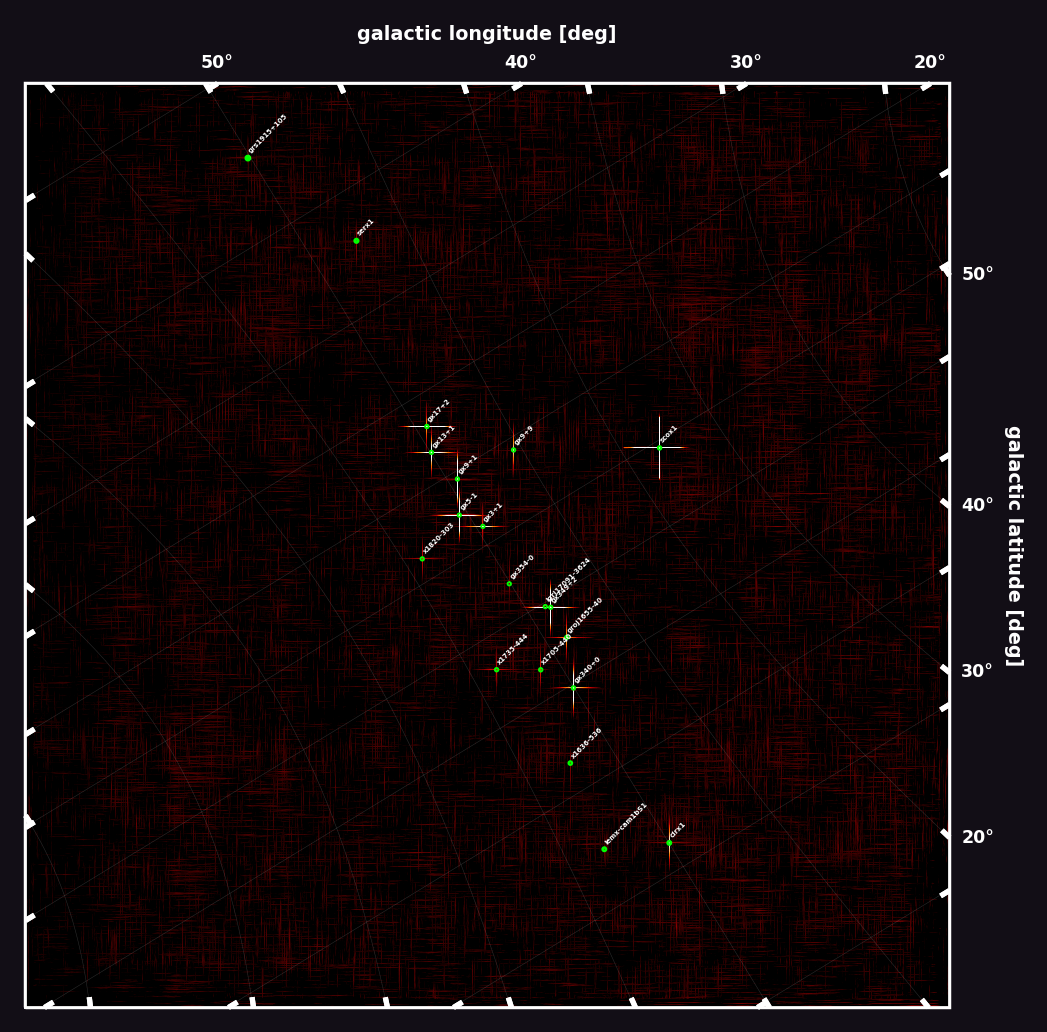

In [7]:
compIROS_out_path = f"{SAVE_PATH}/COMPOSED_OUTsky_IROS_CAM1A_CAM1B.fits"
reg_file_path = f"{SAVE_PATH}/OUTregionfile_IROS_CAM1B.reg"

img, wcs = open_ImageHDU(compIROS_out_path, ext=2)
reg = Regions.read(reg_file_path, format='ds9')

transf: Callable = lambda x: np.pow(np.clip(x, a_min=0.5, a_max=20), 0.75)

show_composed_skymap(
    image=transf(img),
    reg=reg,
    wcs=wcs,
    spacing=10,
    save_to=f'{OUT_RESULTS_PATH}/test_comp.pdf'
)

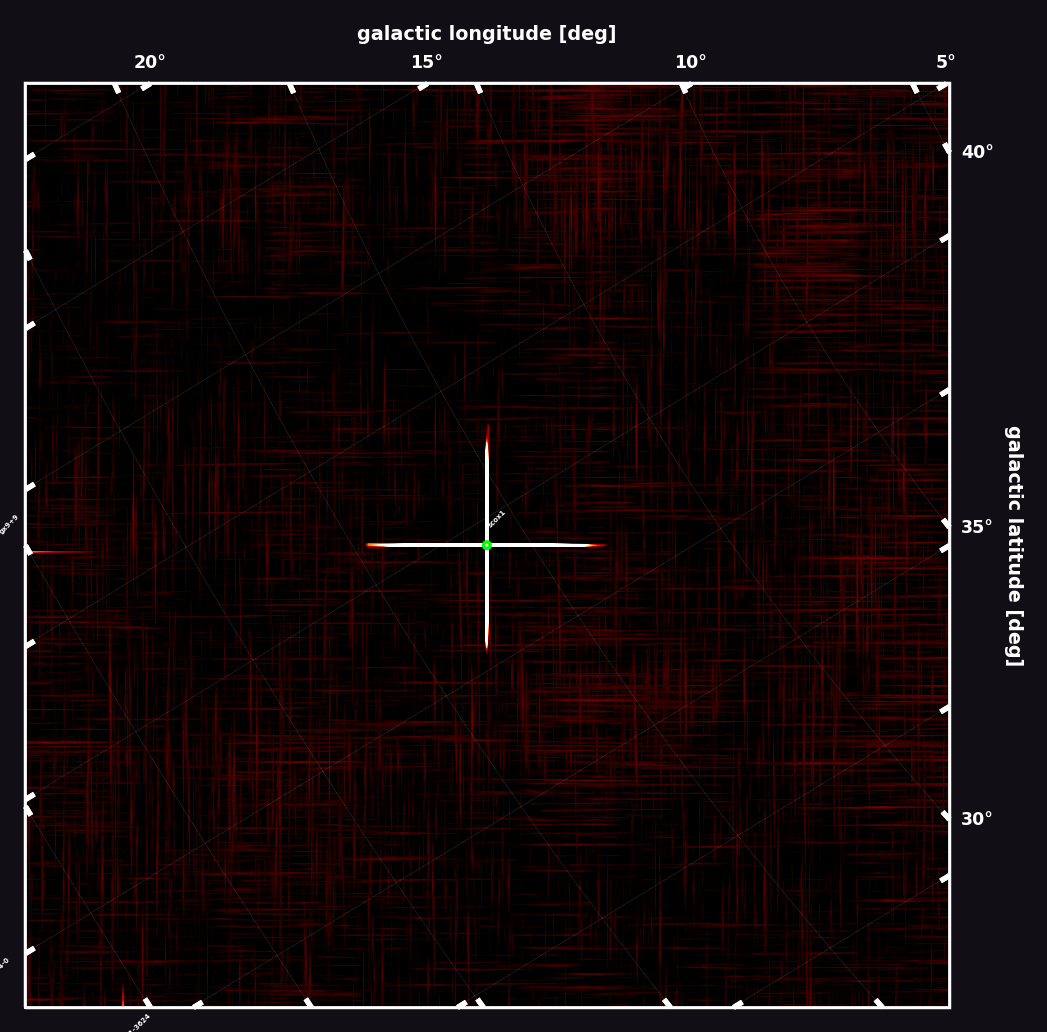

In [8]:
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord

IDX: int = 0   # scox-1

POS: tuple[int, int] = (logA.log['ra'][IDX], logA.log['dec'][IDX])
SIZE: tuple[int, int] = (1000, 1000)

cutout = Cutout2D(img, SkyCoord(ra=POS[0], dec=POS[1], frame='fk5', unit='deg'), SIZE, wcs=wcs)

show_composed_skymap(
    image=transf(cutout.data),
    reg=reg,
    wcs=cutout.wcs,
    spacing=5,
    save_to=f'{OUT_RESULTS_PATH}/test_comp_cutout.pdf'
)

In [9]:
# LEM-X Unit localisation:
#   - src coords residues plot
#   - SNR vs localisation efficiency

### **Sources Statistics**

In [10]:
# SNR distr. vs coding noise reduction

<br>

<br>

<br>

<br>

## <center>**Source Modelling**<center>

In [11]:
from bloodmoon.mask import count, decode, variance
from bloodmoon.optim import model_sky

detector, _ = count(wfm, sdlA.DLdata)
varmap = variance(wfm, detector)
true_skyA = decode(wfm, detector)

## USING BULK MASK with 1.5 mm cover ##


### **PSF Slices**

In [12]:
def custom_slices_plot(
    camera: CodedMaskCamera,
    sky: NDArray | tuple[NDArray],
    pos: tuple[int, int],
    crp: tuple[int, int],
    *,
    title_prefix: str | None = None,
    ylabel: str | None = None,
    ylim_xslice: tuple[Any, Any] | None = None,
    ylim_yslice: tuple[Any, Any] | None = None,
    labels: str | tuple[str | None] | None = None,
    color: str | tuple[str] | None = None,
    save_to: str | Path | None = None,
    **kwargs: Any,
) -> None:
    """
    Plots horizontal and vertical slices of 2D data arrays centered at a given position.
    """
    def phase(x: NDArray) -> NDArray:
        """Centers x-axis values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
    cropped = tuple(
        ds.crop(s, pos, crp, strict=False) for s in (
            (sky,) if isinstance(sky, np.ndarray) else sky
        )
    )
    xslice, yslice = zip(
        *tuple((c[crp[0], :], c[:, crp[1]]) for c in cropped)
    )
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    kws = {
        'ylabel': ylabel or 'counts [ph]',
        'labels': labels,
        'style': 'stairs',
        'color': color,
    }
    dmapx = ds.map4plot(
        arrs=xslice,
        title=f"{title_prefix_}" + "Fine-direction Slice",
        xlabel='$\\theta_{fine}$ [arcmin]',
        x=map(lambda x: dtx * phase(x), xslice),
        ylim=ylim_xslice or (None, None),
        **kws,
    )
    dmapy = ds.map4plot(
        arrs=yslice,
        title=f"{title_prefix_}" + "Coarse-direction Slice",
        xlabel='$\\theta_{coarse}$ [deg]',
        x=map(lambda y: dty * phase(y) / 60, yslice),
        ylim=ylim_yslice or (None, None),
        **kws,
    )
    ds.plot(
        dmaps=(dmapx, dmapy),
        ncols=2,
        save_to=save_to,
        **kwargs,
    )
    return

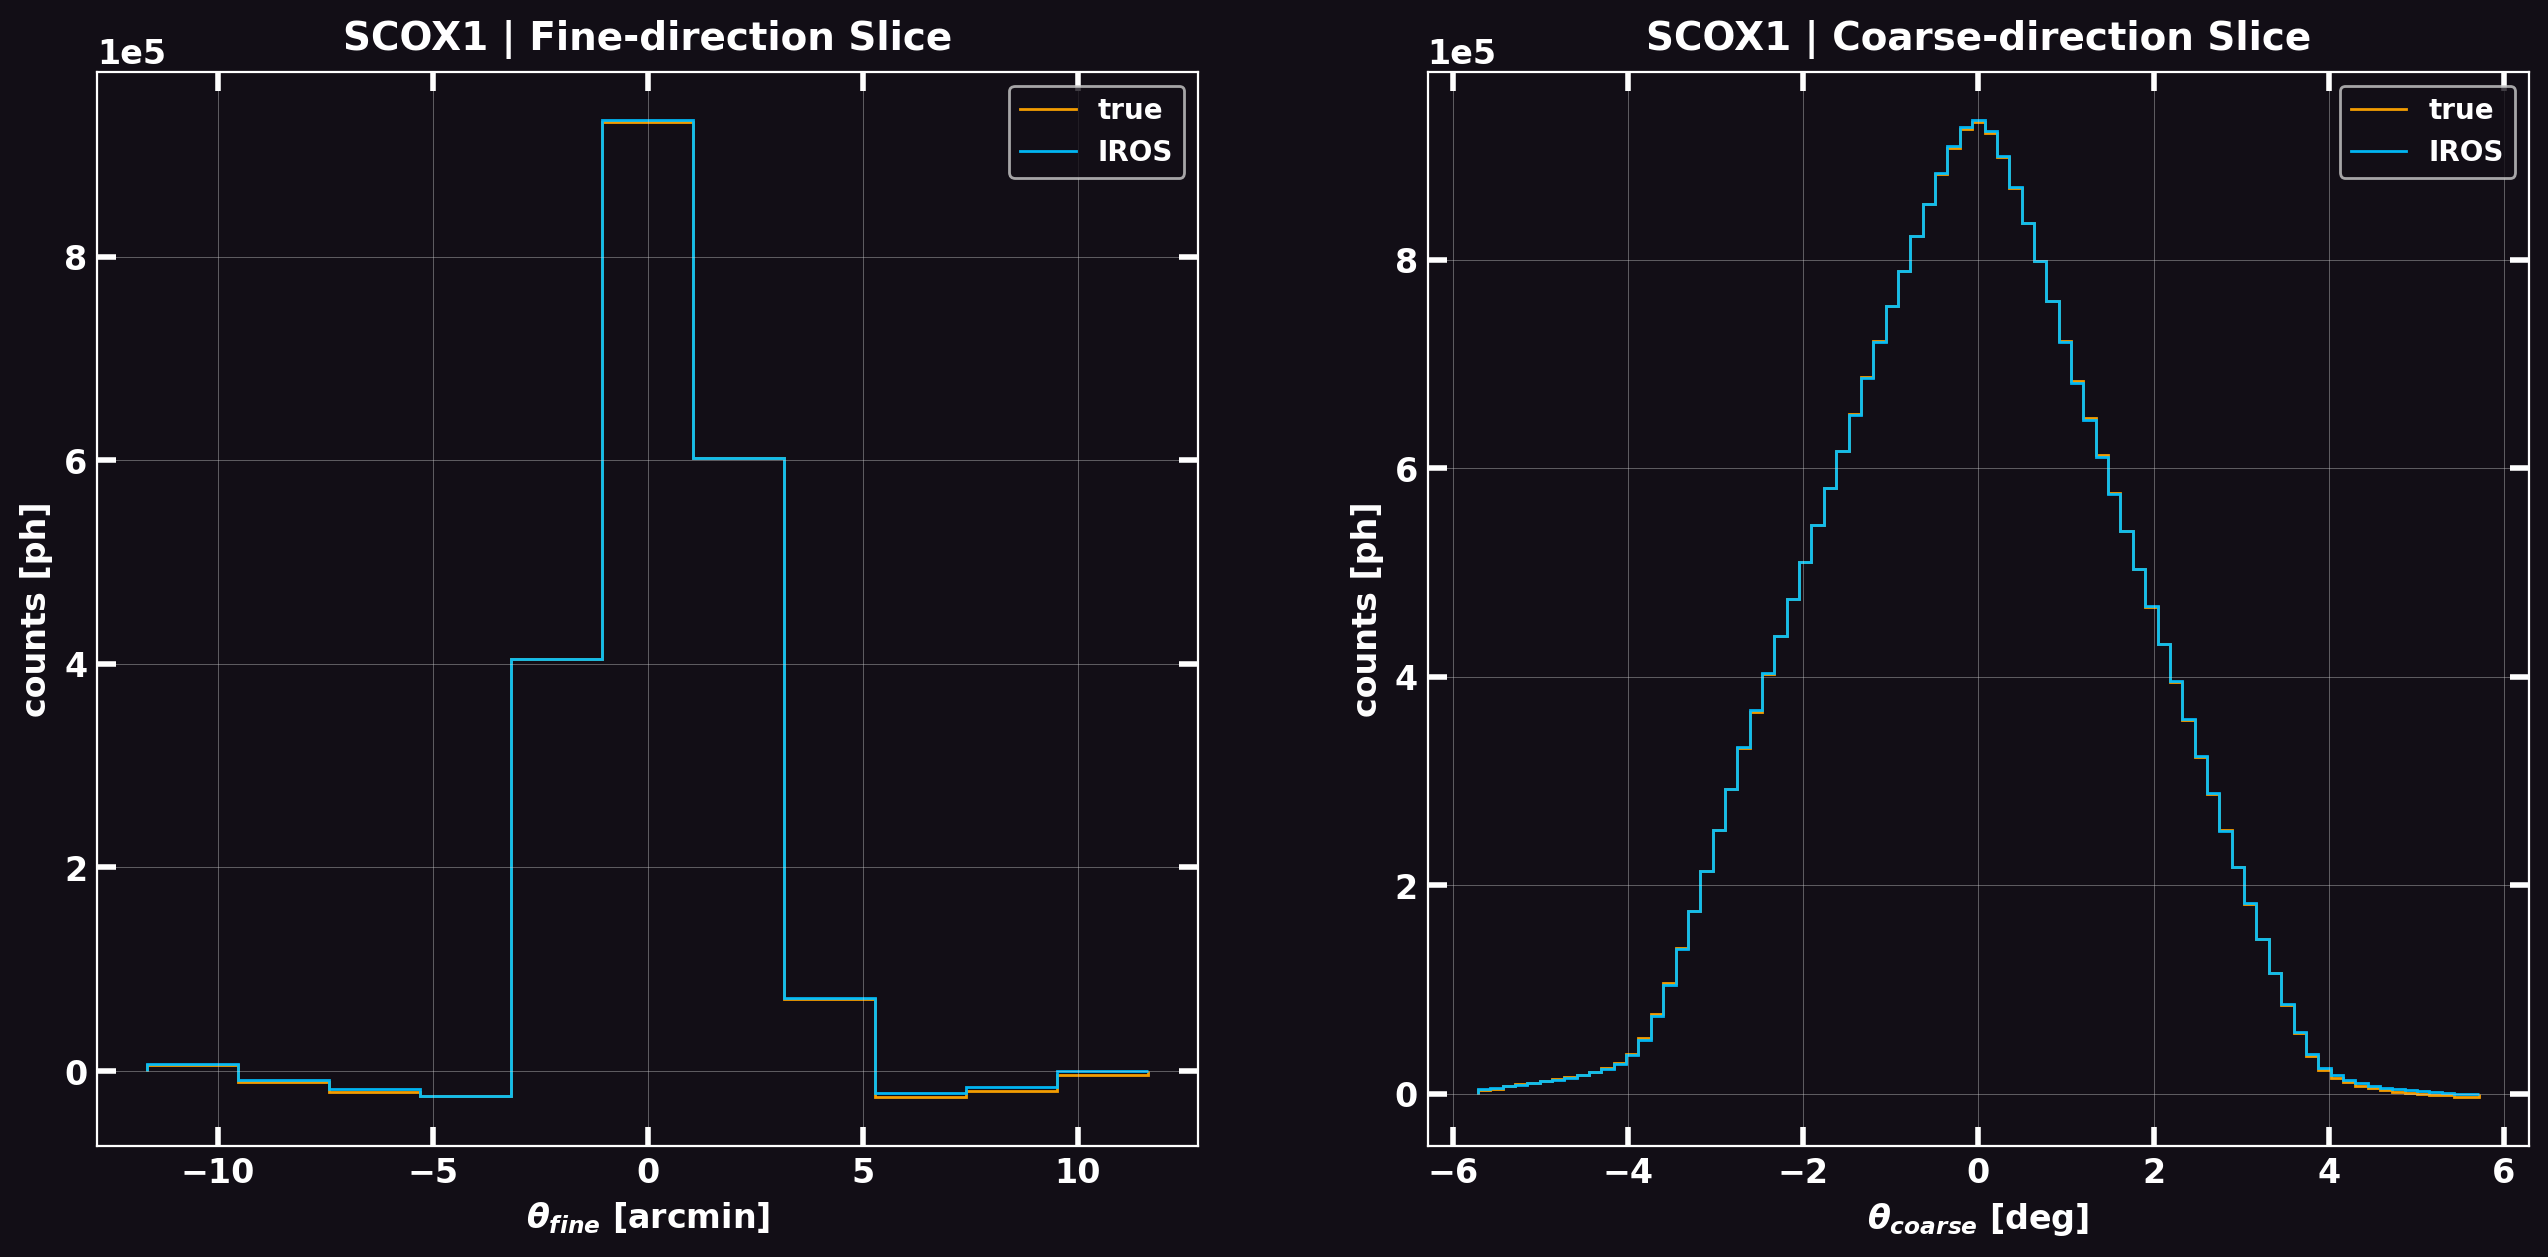

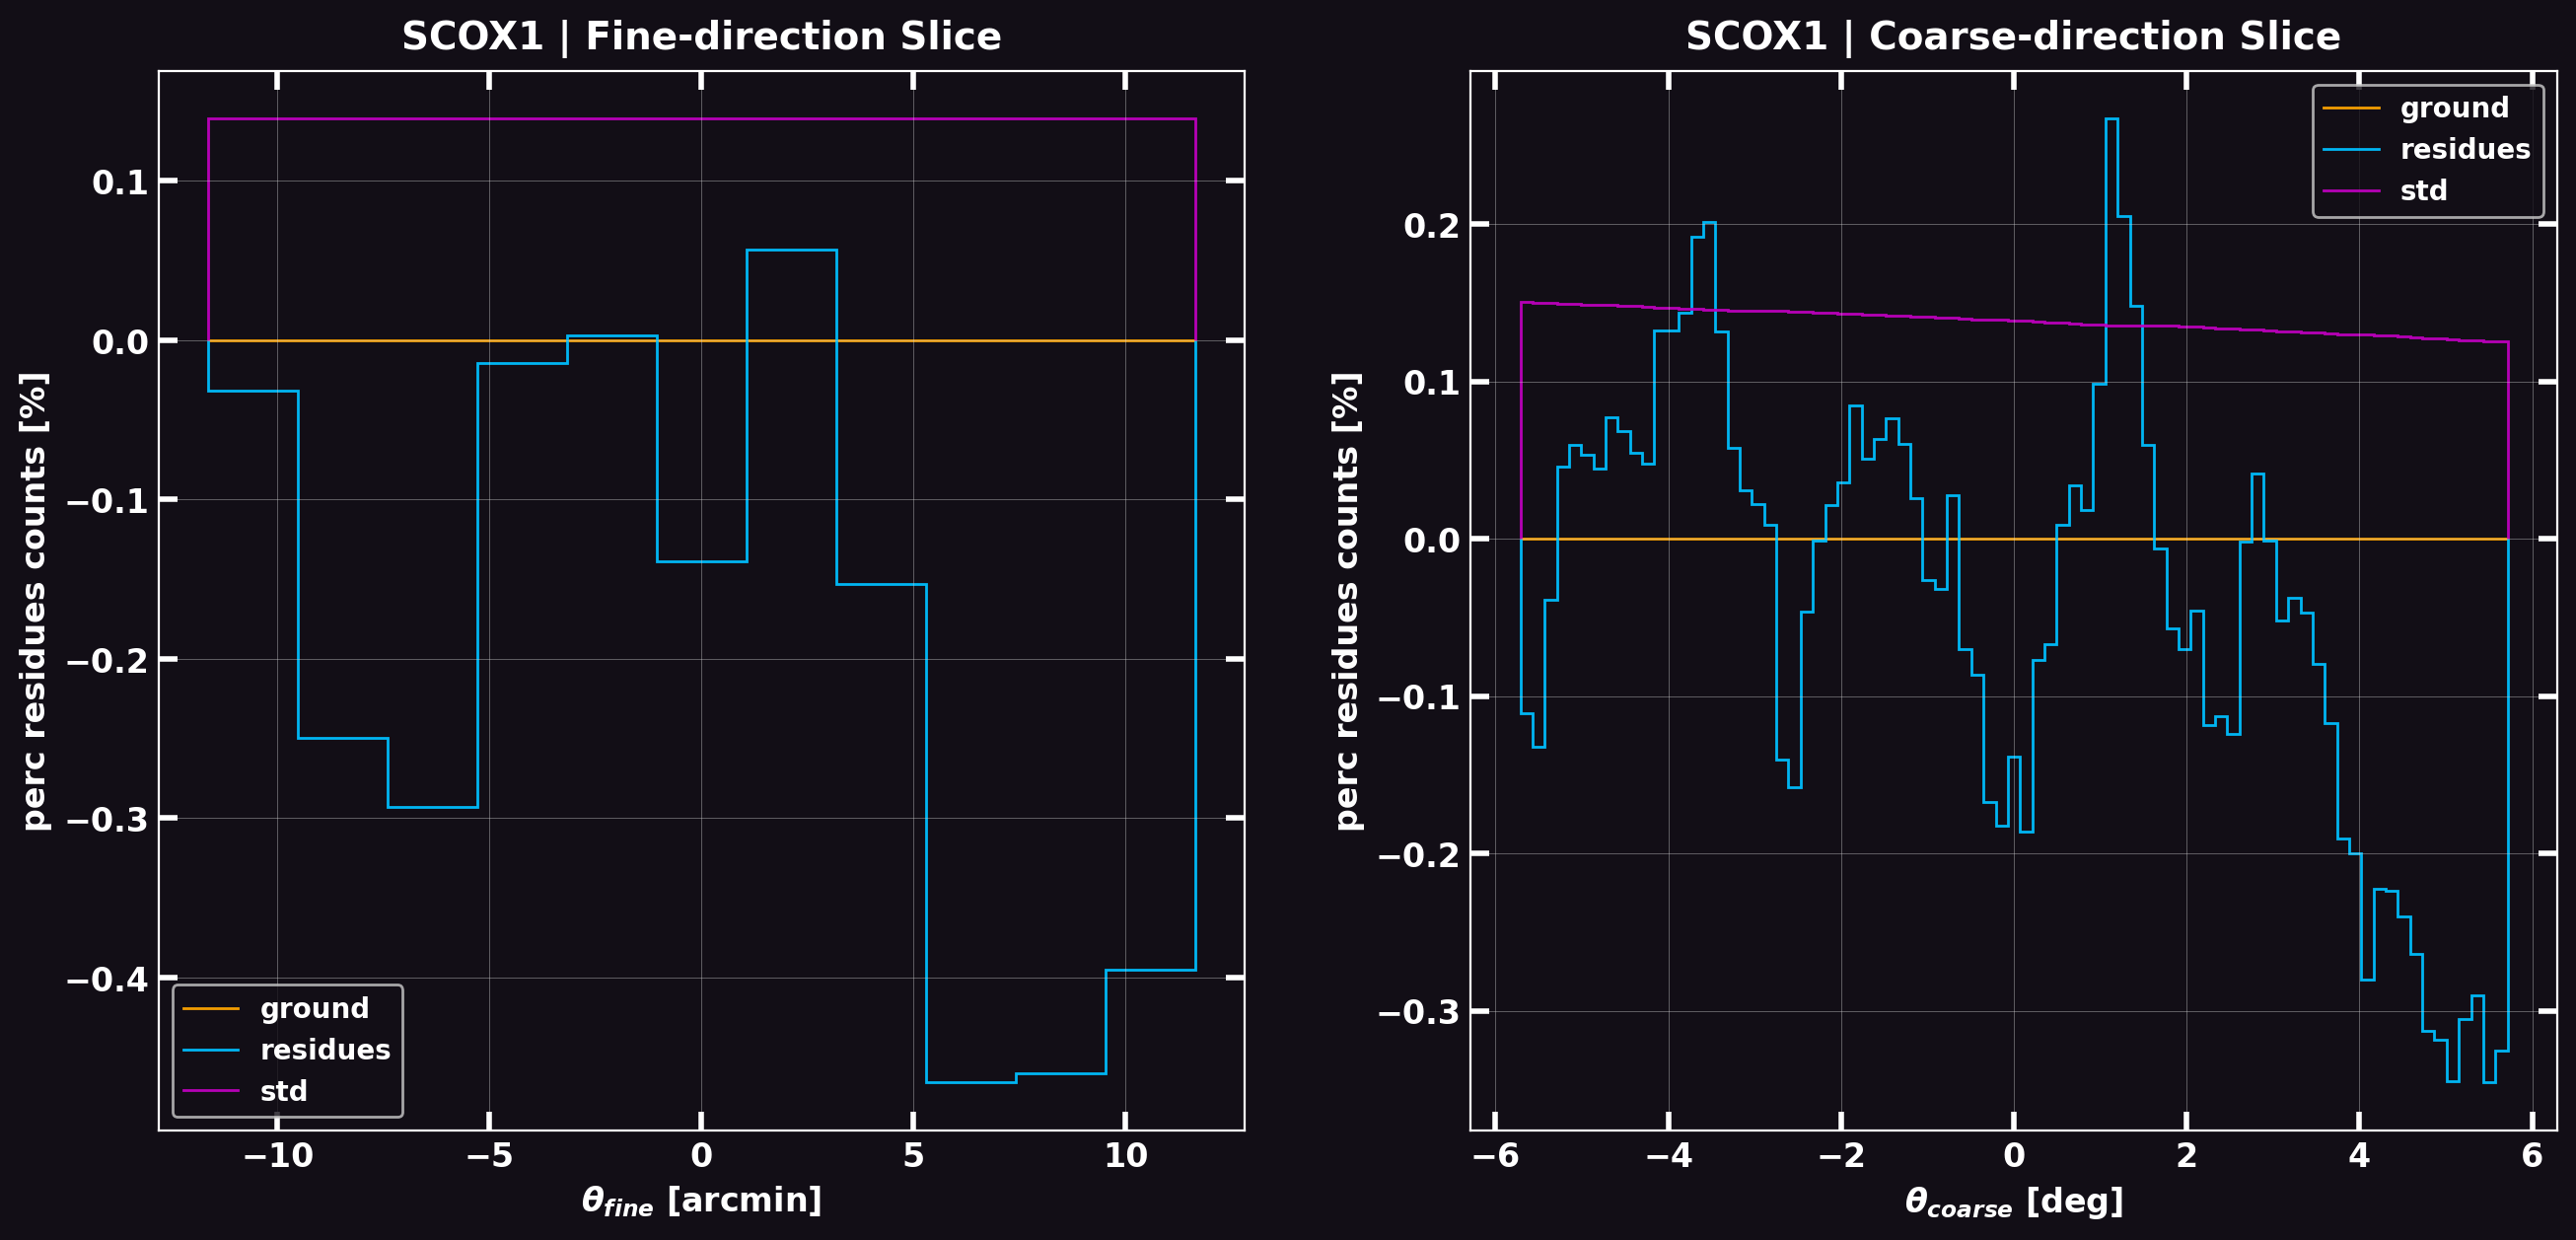

In [13]:
IDX: int = 0   # scox-1
KWS = {
    'pos': (logA.log['y'][IDX], logA.log['x'][IDX]),
    'crp': (40, 5),
    'title_prefix': logA.log['ID'][IDX].upper(),
    'color': ('Orange', 'DeepSkyBlue', 'm'),
}
PERC: bool = True

template = model_sky(wfm, logA.log['shift_x'][IDX], logA.log['shift_y'][IDX], logA.log['fluence'][IDX])
residues = true_skyA - template
loc_std = np.sqrt(varmap)

custom_slices_plot(
    camera=wfm,
    sky=(true_skyA, template),
    labels=('true', 'IROS'),
    save_to=f'{OUT_RESULTS_PATH}/test_psf_slices_{E_min}-{E_max}keV.pdf',
    **KWS,
)
if PERC:
    residues_ = residues * 100 / true_skyA[KWS['pos']]; loc_std_ = loc_std * 100 / true_skyA[KWS['pos']]
else:
    residues_ = residues; loc_std_ = loc_std
custom_slices_plot(
    camera=wfm,
    sky=(np.zeros_like(residues_), residues_, loc_std_),
    labels=('ground', 'residues', 'std'),
    ylabel=r'perc residues counts [%]',
    save_to=f'{OUT_RESULTS_PATH}/test_psf_res_{E_min}-{E_max}keV.pdf',
    **KWS,
)

### **PSF HeatMaps**

In [14]:
def custom_PSF_hmap(
    camera: CodedMaskCamera,
    psf: NDArray,
    residues: NDArray,
    xticks: NDArray,
    yticks: NDArray,
    title_prefix: str | None = None,
    save_to: str | Path | None = None,
) -> None:
    """
    Plots the true PSF of given source and residues wrt `bm` template from IROS.
    """    
    PLOTPARAMS = export_pltparams()
    n, m = psf.shape
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    _yticks_lbl, _xticks_lbl = dty / 60 * (yticks - n // 2), dtx * (xticks - m // 2)
    yticks_lbl, xticks_lbl = map(lambda arr: [float(f'{a:.1f}') for a in arr], (_yticks_lbl, _xticks_lbl))
    aspect = 2 * KWS['crp'][1] / KWS['crp'][0]
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''

    res_ = residues * 100 / psf[(n - 1) // 2, (m - 1) // 2]
    valres = max(abs(res_.min()), abs(res_.max()))

    dsp = DSPlot(2, 1)
    fig, axs = dsp.config_subplots(ptype='image')
    fig.subplots_adjust(wspace=-1e-1)

    # - IMG axis 0  |  PSF
    dsp.config_labels(axs[0], f'{title_prefix_}PSF', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[0].imshow(psf, origin=PLOTPARAMS['cbar_origin'], cmap='gist_heat', aspect=aspect)
    cbar = fig.colorbar(
        img, ax=axs[0], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'counts [ph]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )

    # - IMG axis 1  |  Residues (true-template)
    dsp.config_labels(axs[1], f'{title_prefix_}Residues', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[1].imshow(
        res_, origin=PLOTPARAMS['cbar_origin'], cmap='viridis', aspect=aspect, vmin=-valres, vmax=valres,
    )
    cbar = fig.colorbar(
        img, ax=axs[1], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'perc residues counts [%]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )
    
    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(
            which='both', direction='in', width=3, length=5 if 'major' else 2,
        )
        ax.set_yticks(yticks, yticks_lbl)
        ax.set_xticks(xticks, xticks_lbl)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

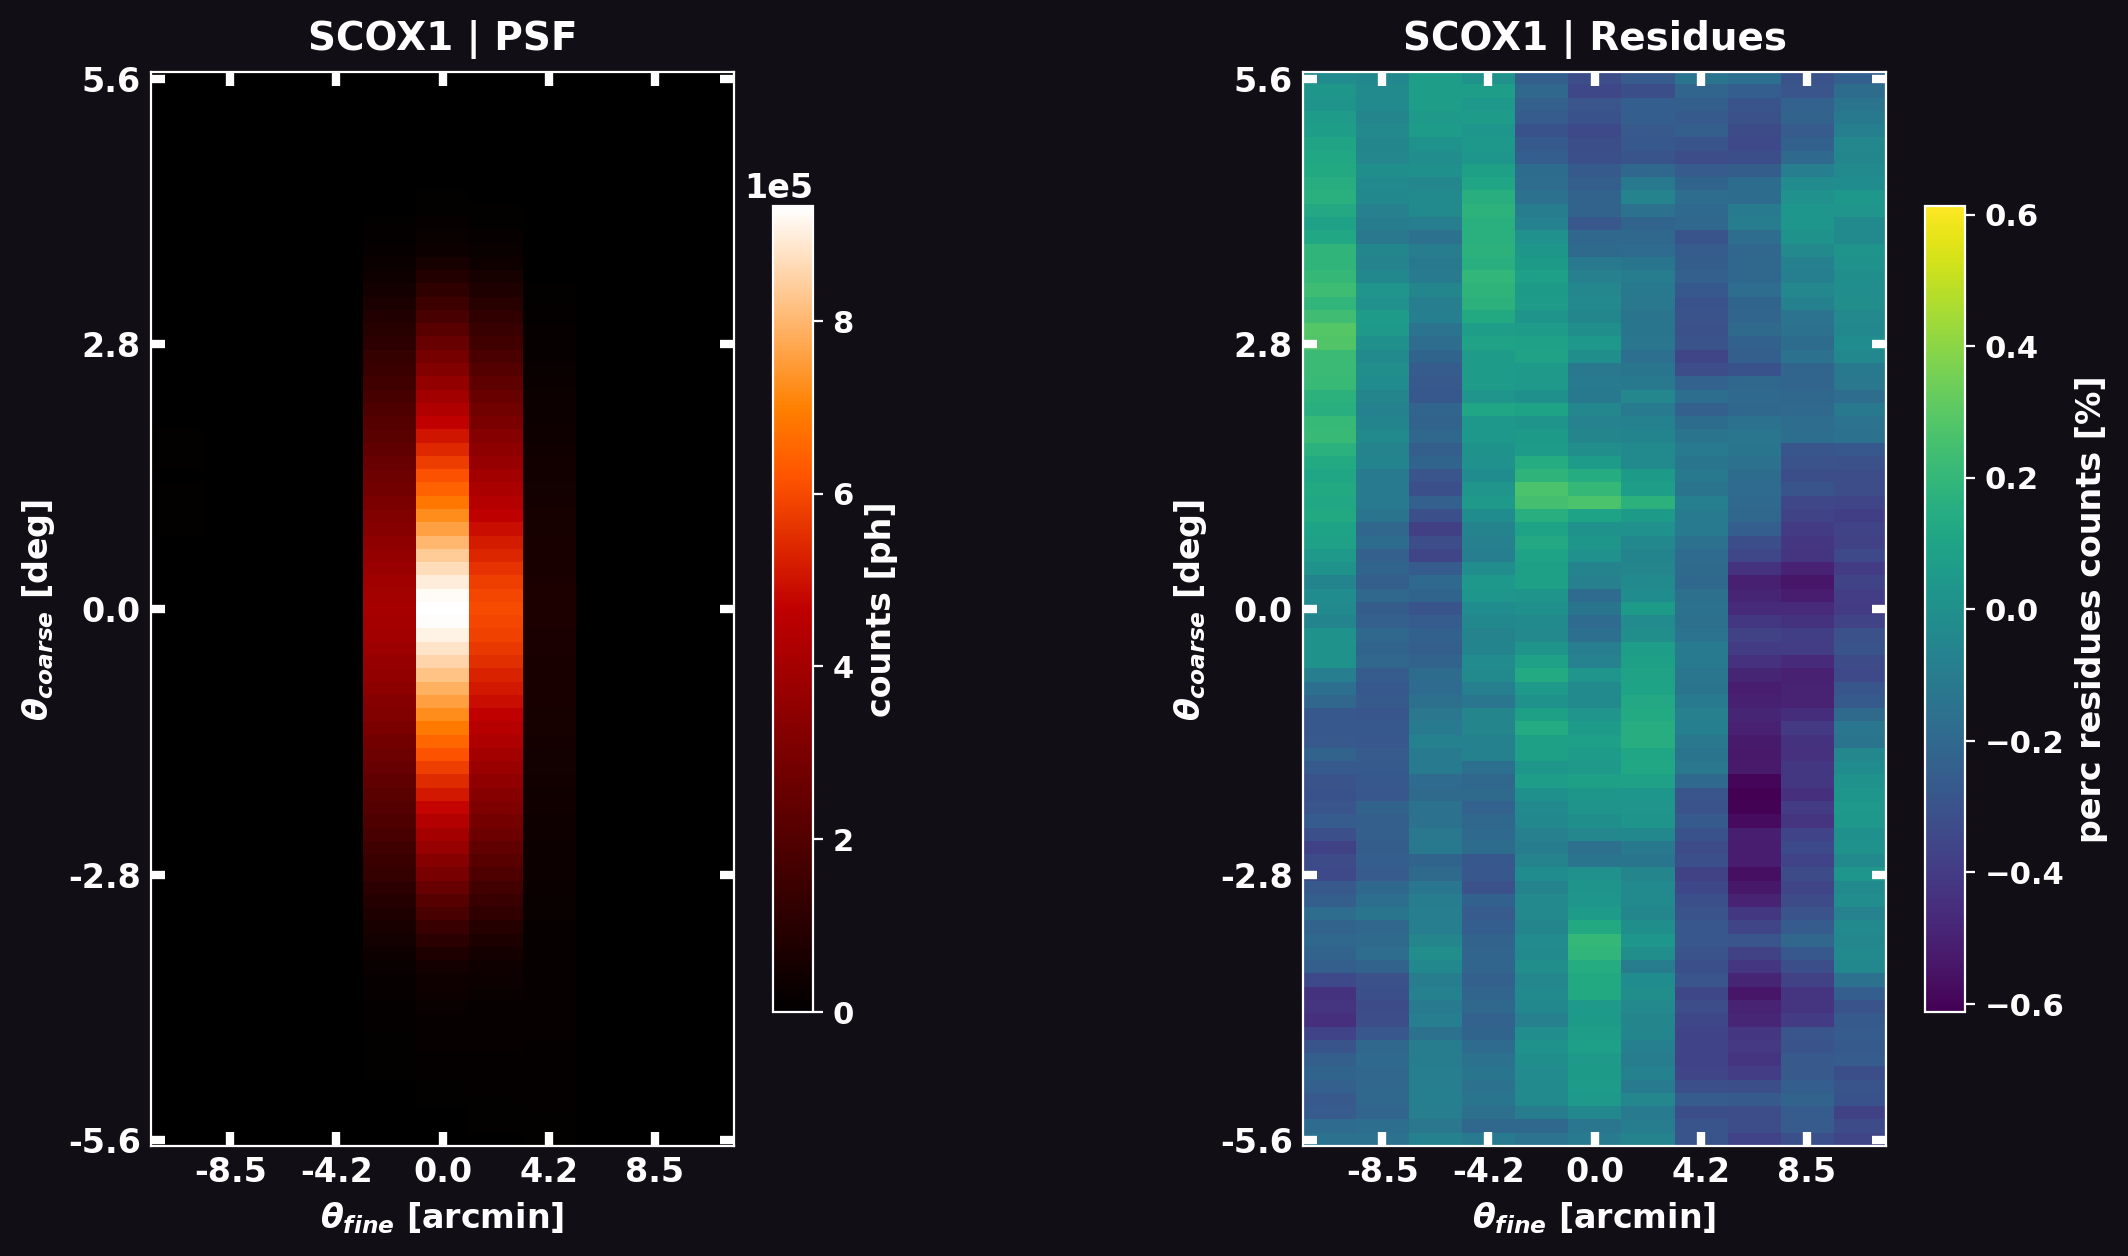

In [15]:
src_psf, src_res = map(lambda x: ds.crop(x, KWS['pos'], KWS['crp']), (true_skyA, residues))

n, m = src_psf.shape
yticks, xticks = np.arange(n)[::20], (np.arange(m)[::2] + 1)[:-1]

custom_PSF_hmap(
    camera=wfm,
    psf=np.clip(src_psf, a_min=0, a_max=src_psf.max()),
    residues=src_res,
    xticks=xticks,
    yticks=yticks,
    title_prefix=KWS['title_prefix'],
    save_to=f'{OUT_RESULTS_PATH}/test_psfHM_{E_min}-{E_max}keV.pdf'
)